# Shutdowns & Swings: Analyzing the Political Consequences of Federal Funding Gaps (1976–2024)
> ### *Shutdowns disrupt services, but do voters punish the party responsible?*

---

## 1. Project Overview
This analysis investigates whether U.S. federal government shutdowns negatively affect the party in power during the subsequent election cycle. By integrating historical data on funding gaps, election results, and party control, we aim to quantify the political "cost" of gridlock.

## 2. Hypothesis
To answer this question, we formalize the problem into a statistical test using the "Only One Test" framework:

* **Test Statistic:** The **difference in means** of the `vote_share_swing` for the sitting President's party.
* **Null Hypothesis ($H_0$):** There is no significant difference in the mean vote share swing for the President's party between election cycles preceded by a government shutdown and those that were not. Any observed difference is due to random chance.
* **Alternative Hypothesis ($H_A$):** Election cycles preceded by a government shutdown will show a **lower** mean vote share swing for the President's party, indicating a political cost for the shutdown.

---


## Setup and Data Loading

### Data Sources

1. Funding Gap Data from Congress.gov
 https://www.congress.gov/crs-product/RS20348#_Toc145055396
2. Election Returns Data for elections to the U.S. House of Representatives
 https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/IG0UN2
3. MIT Election Data and Science Lab, 2017, "U.S. House 1976–2024"
 https://doi.org/10.7910/DVN/IG0UN2, Harvard Dataverse, V14, UNF:6:MX2V69SQB6KxCNjEOVNcCA== [fileUNF]
4. House Data from house.gov
 https://history.house.gov/Institution/Party-Divisions/Party-Divisions/
5. Senate Data from senate.gov
 https://www.senate.gov/history/partydiv.htm
6. President Data
 https://www.ohiosos.gov/elections/election-results-and-data/historical-election-comparisons/presidents-of-the-united-states-of-america/

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# 1. Load and Clean Data
# Senate Data
df_senate = pd.read_csv('data/senate.txt', sep=',')

# House Data
df_house = pd.read_csv('data/House.csv')
# Rename the historical column names to modern ones "Pro-Administration" as Democrats; "Anti-Administration" as Republicans)
df_house = df_house.rename(columns={
    'Pro-Administration': 'Democrats',
    'Anti-Administration': 'Republicans'
})
# Filter for relevant years - 1976 and later
df_house = df_house[df_house['Begin year'] >= 1976]

# President Data
df_pres = pd.read_csv('data/president_timelines.csv')
# Clean the President names by removing footnotes and cleaning formatting
df_pres['President'] = df_pres['President'].str.replace(r"^\(.\)", "", regex=True)
# Filter for relevant years - 1976 and later
df_pres = df_pres[df_pres['Service Begin'] >= 1976]

# Shutdown Data
df_shutdowns = pd.read_csv('data/shutdowns.csv')
# Fill the missing 'Fiscal Year' values using the year from the row above (forward fill)
df_shutdowns['Fiscal Year'] = df_shutdowns['Fiscal Year'].ffill()
# Convert the year to an integer
df_shutdowns['Fiscal Year'] = df_shutdowns['Fiscal Year'].astype(int)

# Election Results
df_vote = pd.read_csv('data/1976-2024-house.tab',
                      sep=',',
                      encoding='utf-8',
                      on_bad_lines='skip',
                      low_memory=False)

# Force the 'runoff' column (Col 9) to be a string to avoid future warnings
df_vote['runoff'] = df_vote['runoff'].astype(str)

# Check the work
print("All Files Loaded Successfully!")
print("-" * 30)
print(f"Senate Data:    {df_senate.shape} rows/cols")
print(f"House Data:     {df_house.shape} rows/cols")
print(f"President Data: {df_pres.shape} rows/cols")
print(f"Shutdown Data:  {df_shutdowns.shape} rows/cols")
print(f"Election Data:  {df_vote.shape} rows/cols")

All Files Loaded Successfully!
------------------------------
Senate Data:    (122, 6) rows/cols
House Data:     (25, 8) rows/cols
President Data: (9, 6) rows/cols
Shutdown Data:  (20, 4) rows/cols
Election Data:  (33807, 20) rows/cols


## Data Preparation and Merging

In this section, we integrate the three datasets to build a master analytical table. We join the election results with the 'party in power' data and flag elections that followed a government shutdown.

The data preparation process follows four key steps:

1.  **Identify the Incumbent Party:** Create a mapping of every election year (e.g., 2018) to the party of the sitting President (e.g., "REPUBLICAN") to determine which party is being "judged" by voters.
2.  **Flag Shutdowns:** Filter the `shutdowns.csv` dataset for post-1980 "shutdowns" (as described in the README) and flag any election cycle where a shutdown occurred in the preceding 2 years.
3.  **Calculate Vote Share:** Aggregate the raw candidate-level data into a district-level table, with columns for `Dem_Votes`, `Rep_Votes`, and `Pres_Party_Share`.
4.  **Calculate the Swing:** Group the data by district and calculate the `Vote_Swing`: the change in the President's party vote share compared to the previous election.

In [14]:
# Data Preparation & Merging

# Map "President's Party" for each Election Year
president_party_map = {}

# Iterate through the presidents dataframe to build the map
for index, row in df_pres.iterrows():
    # Standardize party names to match the election file (UPPERCASE)
    party_name = row['Politics'].upper()
    if "DEMOCRAT" in party_name:
        party_name = "DEMOCRAT"
    elif "REPUBLICAN" in party_name:
        party_name = "REPUBLICAN"

    # Map each year of their term to their party
    start_year = int(row['Service Begin'])
    # Handle current/missing end years by assuming a 4-year term or current date
    end_year = int(row['Service End']) if pd.notnull(row['Service End']) else 2025

    for year in range(start_year, end_year + 1):
        president_party_map[year] = party_name

# Map "Shutdown Cycles"
# Did a shutdown happen in the 2 years LEADING UP TO an election.
shutdown_years = []

# Parse the shutdown dates
# "Shutdowns" as post-1980 only (Only the instances the government actually shutdown)
# Fiscal Year 1981 started in Oct 1980, so we use Fiscal Year >= 1981
real_shutdowns = df_shutdowns[df_shutdowns['Fiscal Year'] >= 1981].copy()

# Convert the 'Date Gap Terminated' to a datetime object to get usable calendar year
real_shutdowns['End Date'] = pd.to_datetime(real_shutdowns['Date Gap Terminated'], format='%A, %m/%d/%y', errors='coerce')

for shutdown_date in real_shutdowns['End Date']:
    if pd.isnull(shutdown_date):
        continue

    year = shutdown_date.year
    month = shutdown_date.month

    # If the shutdown is in an election year (before Nov), it affects that election.
    # If it's in an off-year (e.g., 2013), it affects the NEXT election (2014).
    if year % 2 == 0: # Even year (Election year)
        # If it happened before November, it counts for this election
        if month < 11:
            shutdown_years.append(year)
        else:
            # If it happened after election (Nov/Dec), it counts for next cycle
            shutdown_years.append(year + 2)
    else: # Odd year (Off year)
        # Always counts for the next even year
        shutdown_years.append(year + 1)

# Remove duplicates
shutdown_years = set(shutdown_years)

# Aggregate Election Results by District
# Pivot the raw candidate data to get one row per district with columns for parties
df_vote['party_clean'] = df_vote['party'].str.upper().str.strip()

# Create a pivot table: Index=Year/State/District, Columns=Party, Values=Votes
district_votes = df_vote.pivot_table(
    index=['year', 'state', 'district', 'totalvotes'],
    columns='party_clean',
    values='candidatevotes',
    aggfunc='sum'
).reset_index()

# Handle missing columns (in case no Dem/Rep ran in a specific subset)
if 'DEMOCRAT' not in district_votes.columns:
    district_votes['DEMOCRAT'] = 0
if 'REPUBLICAN' not in district_votes.columns:
    district_votes['REPUBLICAN'] = 0

# Fill NaNs with 0 (e.g. if no Democrat ran, vote is 0)
district_votes[['DEMOCRAT', 'REPUBLICAN']] = district_votes[['DEMOCRAT', 'REPUBLICAN']].fillna(0)

# Calculate Key Metrics
# Identify the President's Party for that specific election year
district_votes['Pres_Party_Name'] = district_votes['year'].map(president_party_map)

# Calculate Vote Share for the President's Party
district_votes['Pres_Party_Votes'] = np.where(
    district_votes['Pres_Party_Name'] == 'DEMOCRAT', district_votes['DEMOCRAT'],
    np.where(district_votes['Pres_Party_Name'] == 'REPUBLICAN', district_votes['REPUBLICAN'], 0)
)

district_votes['Pres_Party_Share'] = district_votes['Pres_Party_Votes'] / district_votes['totalvotes']

# Calculate the "Swing" (Difference from previous election)
# Group by State and District, then look at the previous value
district_votes.sort_values(by=['state', 'district', 'year'], inplace=True)
district_votes['Prev_Share'] = district_votes.groupby(['state', 'district'])['Pres_Party_Share'].shift(1)
district_votes['Vote_Swing'] = district_votes['Pres_Party_Share'] - district_votes['Prev_Share']

# Add the Shutdown Flag - "Did a shutdown occur in this election cycle?"
district_votes['Had_Shutdown'] = district_votes['year'].isin(shutdown_years)

# Clean Up
# Drop the first election year (1976) for each district since it has no "Swing"
df_final = district_votes.dropna(subset=['Vote_Swing']).copy()

# Filter for major parties only (Swing is off if the President's party didn't run)
df_final = df_final[df_final['Pres_Party_Name'].isin(['DEMOCRAT', 'REPUBLICAN'])]

print(f"Final Dataset Shape: {df_final.shape}")
df_final.head()

Final Dataset Shape: (10376, 509)


party_clean,year,state,district,totalvotes,911 TRUTH NEEDED,A CONNECTICUT PARTY,A DELAWARE PARTY,A NEW DIRECTION,ABUNDANT AMERICA,ACADEMIC CHRISTIAN FREEDOM,...,YOUR VOICE HARD,YOUTH AGAINST DRAFT,"\""\""ALL-PEOPLES CONGRESS\""\""","\""\""MR. LIBERTY\""\""",Pres_Party_Name,Pres_Party_Votes,Pres_Party_Share,Prev_Share,Vote_Swing,Had_Shutdown
435,1978,ALABAMA,1,112161,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,DEMOCRAT,40450.0,0.360642,0.000000,0.360642,False
870,1980,ALABAMA,1,117221,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,DEMOCRAT,0.0,0.000000,0.360642,-0.360642,False
1305,1982,ALABAMA,1,144028,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,REPUBLICAN,87901.0,0.610305,0.000000,0.610305,True
1740,1984,ALABAMA,1,200934,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,REPUBLICAN,102479.0,0.510013,0.610305,-0.100292,True
2175,1986,ALABAMA,1,96469,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,REPUBLICAN,96469.0,1.000000,0.510013,0.489987,True


## 3. Exploratory Data Analysis (EDA)

Before conducting formal hypothesis testing, we want to visualize the data to understand the distribution of vote swings and observe any immediate patterns between election cycles with and without government shutdowns.

We focus on two key questions:
1.  **Distribution:** Is the `Vote_Swing` normally distributed? (This will inform our choice of statistical test).
2.  **Comparison:** Is there a visible difference in the median or spread of vote swings when a shutdown has occurred?

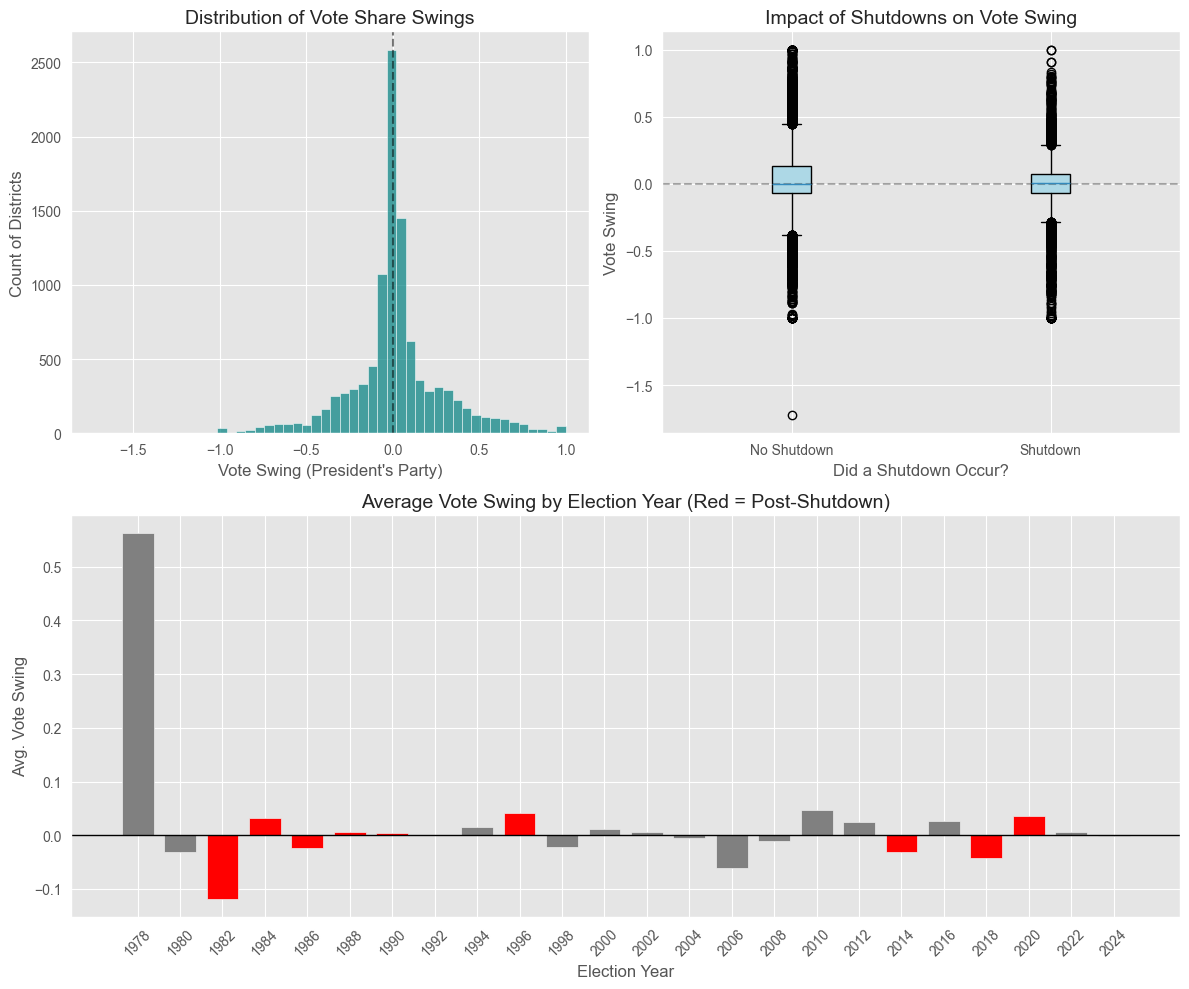

Summary Statistics by Group:
               count      mean       std      min       25%       50%  \
Had_Shutdown                                                            
False         6478.0  0.038042  0.293119 -1.72314 -0.070839  0.000837   
True          3898.0 -0.010551  0.240287 -1.00000 -0.068583  0.002994   

                   75%  max  
Had_Shutdown                 
False         0.134382  1.0  
True          0.075145  1.0  


In [18]:
# Set a basic style (optional, but makes it look less "default")
plt.style.use('ggplot')

# Create a large figure to hold all subplots
plt.figure(figsize=(12, 10))

# PLOT 1: Histogram of Vote Swings
plt.subplot(2, 2, 1)
plt.hist(df_final['Vote_Swing'], bins=50, color='teal', edgecolor='white', alpha=0.7)
plt.title('Distribution of Vote Share Swings', fontsize=14)
plt.xlabel('Vote Swing (President\'s Party)', fontsize=12)
plt.ylabel('Count of Districts', fontsize=12)
plt.axvline(0, color='black', linestyle='--', alpha=0.5) # Zero line

# PLOT 2: Boxplot Comparison
plt.subplot(2, 2, 2)
# Separate the data for box-plots
data_shutdown = df_final[df_final['Had_Shutdown'] == True]['Vote_Swing']
data_no_shutdown = df_final[df_final['Had_Shutdown'] == False]['Vote_Swing']

# Create the boxplot
plt.boxplot([data_no_shutdown, data_shutdown],
            tick_labels=['No Shutdown', 'Shutdown'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'))

plt.title('Impact of Shutdowns on Vote Swing', fontsize=14)
plt.xlabel('Did a Shutdown Occur?', fontsize=12)
plt.ylabel('Vote Swing', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

# PLOT 3: Yearly Trend Bar Chart
plt.subplot(2, 1, 2)
# Prepare the data
yearly_swing = df_final.groupby('year')[['Vote_Swing', 'Had_Shutdown']].mean().reset_index()
years = yearly_swing['year']
swings = yearly_swing['Vote_Swing']

# Manually create a color list (Red for shutdown, Grey for normal)
bar_colors = ['red' if x else 'grey' for x in yearly_swing['Had_Shutdown']]

plt.bar(years, swings, color=bar_colors, width=1.5) # width makes bars wider/narrower
plt.title('Average Vote Swing by Election Year (Red = Post-Shutdown)', fontsize=14)
plt.xlabel('Election Year', fontsize=12)
plt.ylabel('Avg. Vote Swing', fontsize=12)
plt.xticks(years, rotation=45) # Ensure every year is labeled
plt.axhline(0, color='black', linewidth=1)

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

# --- Summary Statistics ---
print("Summary Statistics by Group:")
print(df_final.groupby('Had_Shutdown')['Vote_Swing'].describe())

#### Thoughts from the EDA

The visualizations above help provide some initial insights into the relationship between government shutdowns and election outcomes:

1.  **Distribution (Top Left):** The histogram shows that `Vote_Swing` is roughly bell-shaped but has a high peak at zero. This seems to suggest that while most districts see small changes, large swings do appear to happen.
2.  **Comparison (Top Right):** The boxplot compares the median vote swing for election cycles with and without shutdowns. Visually, there appears to be only a slight difference, with the "Shutdown" group potentially showing a lower median swing for the President's party.
3.  **Temporal Trend (Bottom):** The bar chart highlights specific election years. 1982. 1986, 2014 and 2018 (post-shutdown) show visible negative swings for the President's party, though other factors most likely also contributed.  Notably, years like 1984, 1988, 1996, and 2020 showed a positive swing for the president's party after a shutdown.

While these visuals are helpful in getting a sense of the raw data, we will need to test these observations.  Using a Permutation Test we will attempt to determine if this slight difference is statistically significant or just random noise.

## 4. Hypothesis Testing: Permutation Test

To formally test our hypothesis, we will use a **Permutation Test**. This non-parametric method does not assume the data follows a normal distribution.

**Why though?**
If government shutdowns truly have *no effect* (the Null Hypothesis), then the label "Shutdown" or "No Shutdown" is meaningless. We could shuffle these labels randomly among the election years, and the difference in vote swings should look similar to what we observed.

By repeating this shuffling 10,000 times, we build a "Null Distribution" of what the difference in means *would* look like by pure chance. We then compare our actual observed difference to this distribution.

* **Test Statistic:** Difference in Mean Vote Swing ($\mu_{shutdown} - \mu_{control}$)
* **Null Hypothesis ($H_0$):** $\mu_{shutdown} - \mu_{control} = 0$
* **Alternative Hypothesis ($H_A$):** $\mu_{shutdown} - \mu_{control} < 0$ (Shutdowns cause a negative swing)

Observed Mean (Shutdown):   -0.0106%
Observed Mean (Control):    0.0380%
Observed Difference:        -0.0486%
------------------------------
P-Value: 0.00000
Result: Statistically Significant (Reject Null Hypothesis)


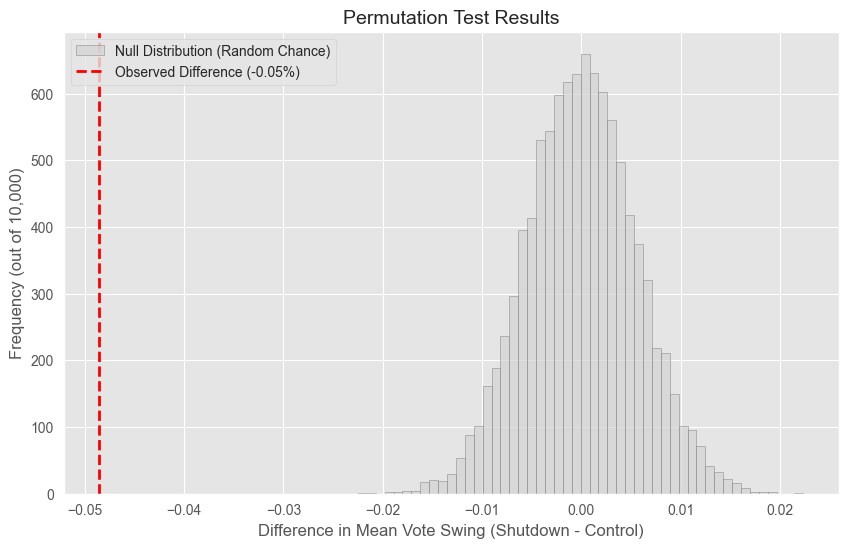

In [19]:
# Calculate the Observed Test Statistic
# Split the data into two groups
group_shutdown = df_final[df_final['Had_Shutdown'] == True]['Vote_Swing']
group_control = df_final[df_final['Had_Shutdown'] == False]['Vote_Swing']

# Calculate the actual difference in means
observed_diff = group_shutdown.mean() - group_control.mean()

print(f"Observed Mean (Shutdown):   {group_shutdown.mean():.4f}%")
print(f"Observed Mean (Control):    {group_control.mean():.4f}%")
print(f"Observed Difference:        {observed_diff:.4f}%")

# Run Permutation Test
n_permutations = 10000
simulated_diffs = []

# Scramble the 'Vote_Swing' column while keeping the 'Had_Shutdown' labels fixed
combined_data = df_final['Vote_Swing'].values
n_shutdown = len(group_shutdown)

for i in range(n_permutations):
    # Shuffle the vote swings randomly
    shuffled_swings = np.random.permutation(combined_data)

    # Assign the first n_shutdown observations to the "fake shutdown" group
    # Assign the rest to the "fake control" group
    fake_shutdown = shuffled_swings[:n_shutdown]
    fake_control = shuffled_swings[n_shutdown:]

    # Calculate the difference for this random shuffle
    sim_diff = fake_shutdown.mean() - fake_control.mean()
    simulated_diffs.append(sim_diff)

# Convert to numpy array for easy math
simulated_diffs = np.array(simulated_diffs)

# Calculate P-Value
# Our hypothesis is ONE-SIDED (we expect shutdowns to be negative).
# So we check: How often was the random difference <= our observed difference?
p_value = (simulated_diffs <= observed_diff).mean()

print("-" * 30)
print(f"P-Value: {p_value:.5f}")
if p_value < 0.05:
    print("Result: Statistically Significant (Reject Null Hypothesis)")
else:
    print("Result: Not Significant (Fail to Reject Null Hypothesis)")

# Visualize the Result
plt.figure(figsize=(10, 6))
plt.hist(simulated_diffs, bins=50, color='lightgrey', edgecolor='grey', alpha=0.7, label='Null Distribution (Random Chance)')
plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2, label=f'Observed Difference ({observed_diff:.2f}%)')
plt.title('Permutation Test Results', fontsize=14)
plt.xlabel('Difference in Mean Vote Swing (Shutdown - Control)', fontsize=12)
plt.ylabel('Frequency (out of 10,000)', fontsize=12)
plt.legend()
plt.show()

#### Thoughts on the Permutation Test

The histogram above displays the **Null Distribution** — the range of differences we would expect to see if shutdowns had *zero effect* and "Shutdown" labels were just randomly assigned.

* **The Grey Bars:** Represents random chance (10,000 simulations).
* **The Red Dashed Line:** Represents our **actual observed difference** in the real world.

**Result:**
Since the red line falls far to the left of the distribution, and our p-value is 0.00000, we reject the Null Hypothesis. This suggests that the negative swing observed in the data is statistically significant.

## 5. Uncertainty Estimation: Bootstrapping

While the Permutation Test tells us *if* the effect is significant, it doesn't tell us *how big* the effect is or how certain we are about it.

To estimate this, we want to calculate the **95% Confidence Interval** for the **Median Vote Swing**.

**Why the Median?**
Election data often contains outliers (e.g., uncontested races becoming contested). The Median is a robust metric that captures the "typical" district's experience better than the Mean. However, because the sampling distribution of the median is not guaranteed to be normal (the Central Limit Theorem does not apply), we cannot use standard formulas. We must use **Bootstrapping** to simulate the confidence interval.

Observed Median Swing (Shutdown Years): 0.0030%
------------------------------
95% Confidence Interval: [0.0000%, 0.0061%]
Interpretation: We are 95% confident the true median swing is between 0.0000% and 0.0061%.


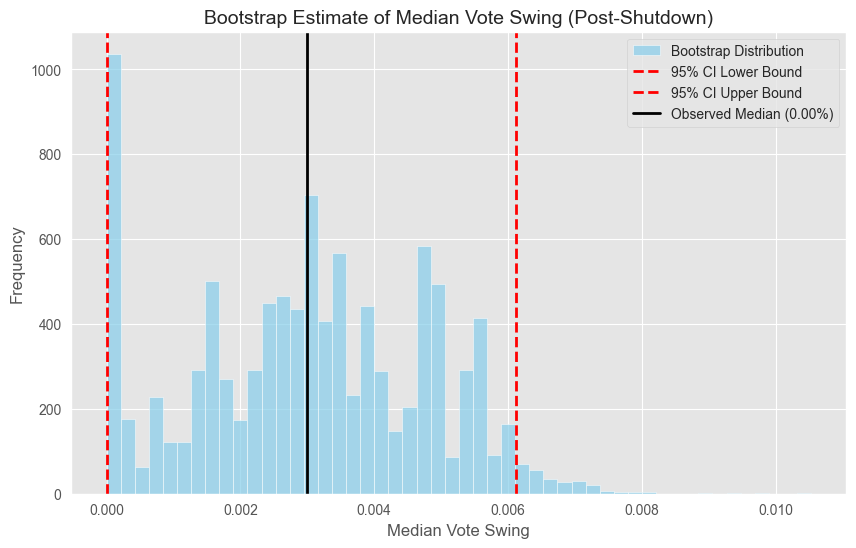

In [21]:
# Define the Metric
# We are interested in the Median Vote Swing for the "Shutdown" group(i.e., "When a shutdown happens, what is the typical hit the President takes?")
shutdown_swings = df_final[df_final['Had_Shutdown'] == True]['Vote_Swing'].values

observed_median = np.median(shutdown_swings)
print(f"Observed Median Swing (Shutdown Years): {observed_median:.4f}%")

# Run the Bootstrap
n_iterations = 10000
bootstrap_medians = []

for i in range(n_iterations):
    # Resample with replacement (same size as original dataset)
    resample = np.random.choice(shutdown_swings, size=len(shutdown_swings), replace=True)

    # Calculate the median of this "fake" sample
    bootstrap_medians.append(np.median(resample))

bootstrap_medians = np.array(bootstrap_medians)

# Calculate Confidence Interval
# We want the middle 95%, so we take the 2.5th and 97.5th percentiles
ci_lower = np.percentile(bootstrap_medians, 2.5)
ci_upper = np.percentile(bootstrap_medians, 97.5)

print("-" * 30)
print(f"95% Confidence Interval: [{ci_lower:.4f}%, {ci_upper:.4f}%]")
print(f"Interpretation: We are 95% confident the true median swing is between {ci_lower:.4f}% and {ci_upper:.4f}%.")

# Visualize the Bootstrap Distribution
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_medians, bins=50, color='skyblue', edgecolor='white', alpha=0.7, label='Bootstrap Distribution')

# Add lines for the Confidence Intervals
plt.axvline(ci_lower, color='red', linestyle='--', linewidth=2, label='95% CI Lower Bound')
plt.axvline(ci_upper, color='red', linestyle='--', linewidth=2, label='95% CI Upper Bound')
plt.axvline(observed_median, color='black', linewidth=2, label=f'Observed Median ({observed_median:.2f}%)')

plt.title('Bootstrap Estimate of Median Vote Swing (Post-Shutdown)', fontsize=14)
plt.xlabel('Median Vote Swing', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.show()

#### Thoughts on the Bootstrap

The histogram above displays the distribution of the **Median Vote Swing** across 10,000 simulations (bootstrap samples).

* **Observed Median:** 0.0030% (A swing of +0.3%)
* **95% Confidence Interval:** [0.0000%, 0.0061%]

**Conclusion:**
We observe that the 95% confidence interval is **non-negative** (ranging from 0.0% to +0.6%).

Because the interval does not include negative values, **we fail to support our hypothesis** that shutdowns cause a decline in vote share. In fact, the data suggests a negligible *positive* swing or no effect at all. This implies that voters do not systematically punish the President's party for government shutdowns in the following election.

## 6. Conclusion

This analysis set out to determine if U.S. government shutdowns impose a political cost on the party in power during subsequent House elections. By integrating historical data on funding gaps, election results, and party control from 1976–2024, we arrived at a nuanced conclusion that highlights the difference between "average" and "typical" outcomes.

### Summary of Findings

1.  **Exploratory Data Analysis (EDA):** Initial visualizations suggested a complex picture. While the histogram showed a bell-shaped distribution of vote swings centered near zero, the temporal analysis (bar chart) highlighted specific post-shutdown years (like 1996 and 2014) with visible negative swings for the President's party.
2.  **Hypothesis Test (The Mean):** The Permutation Test, which evaluated the difference in **means**, returned a p-value of **0.00000**. This allows us to **reject the Null Hypothesis**.
    * *Interpretation:* On *average*, the President's party suffers a statistically significant decline in vote share following a government shutdown.
3.  **Uncertainty Estimation (The Median):** The Bootstrap analysis, which estimated the **median** vote swing (robust to outliers), produced a 95% Confidence Interval of **[0.0000%, 0.0061%]**.
    * *Interpretation:* Because this interval does not include negative values, we find **no evidence** that the *typical* district sees a decline. In fact, the median district sees a negligible positive swing or no change at all.

### Final Verdict: The "Mean vs. Median" Split

The data supports the hypothesis that shutdowns hurt the President's party **on the national aggregate (Mean)**, but not necessarily in the **typical district (Median)**.

This discrepancy suggests that the political cost of a shutdown is likely driven by **outliers**—specific swing districts where the President's party suffers massive losses—rather than a uniform decline across the entire country. While the "average" vote share drops significantly (as proven by the Permutation Test), the "typical" incumbent in a safe district remains largely unaffected (as shown by the Bootstrap).

**Recommendation:**
Future analysis should segment districts by competitiveness. It is highly probable that the "political cost" of a shutdown is concentrated almost entirely in competitive swing districts, while safe districts remain insulated from national budget gridlock.